In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os

def read_MoM_results(individual_sizes, path, file_name, num_snp):
    """
    read_MoM_results from cluster output files.

    parameters:
    individual_sizes: list of individual sizes (e.g., [1000, 2000, 4000])
    path: directory path where the result files are stored
    num_snp: number of SNPs used in the analysis
    file_name: base name of the result files (e.g., "MoM_results")

    returns:
    A dictionary with individual sizes as keys and corresponding DataFrames as values.
    """ 

    data_dict = {}
    for n in individual_sizes:
        full_file_name = f"{file_name}_n{n}m{num_snp}.txt"  # different variable
        file_path = os.path.join(path, full_file_name)
        
        df = pd.read_csv(file_path, header=None)
        df[0] = df[0].astype(str).str.replace('(', '', regex=False).astype(float)
        df[1] = df[1].astype(str).str.replace(')', '', regex=False).astype(float)
        
        data_dict[n] = df
        
    return data_dict

def plot_relative_error_across_groups_combined(*data_dicts, x_labels, individual_sizes, col_num, real_value, ymin, ymax, x_axis_name="Group", title=None, save_name=None):
    """
    Plot relative errors with box plots in journal style.
    
    Parameters:
    -----------
    save_name : str
        Filename without extension (e.g., 'my_plot'). 
        PDF will be saved to the same directory as the script.
        If None, plot is only displayed.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import os
    from scipy import stats
    
    # Set high-quality rendering
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 10,
        'axes.linewidth': 1,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.width': 1,
        'ytick.major.width': 1,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'figure.dpi': 150,
        'savefig.dpi': 600,
    })
    
    # Gather data for all combinations
    data_list = []
    combined_labels = []
    bottom_labels = []
    
    for label, data_dict in zip(x_labels, data_dicts):
        for n in individual_sizes:
            df = data_dict[n]
            col_values = df.iloc[:, col_num].values - real_value
            combined_labels.append(f"{label}\nn={n:,}")
            bottom_labels.append(f"n = {n:,}")
            data_list.append(pd.DataFrame({"value": col_values, "group": combined_labels[-1]}))
    
    data = pd.concat(data_list, ignore_index=True)
    data["group"] = pd.Categorical(data["group"], categories=combined_labels, ordered=True)
    
    # Compute summary statistics
    summary = (
        data.groupby("group", observed=True)["value"]
        .agg(["mean", "std", "count"])
        .loc[combined_labels]
    )
    
    # Perform one-sample t-test for each group (mean != 0)
    p_values = {}
    for combined_label in combined_labels:
        group_data = data[data["group"] == combined_label]["value"].values
        t_stat, p_val = stats.ttest_1samp(group_data, 0)
        p_values[combined_label] = p_val
    
    summary["p_value"] = summary.index.map(p_values)
    
    # x-axis positions
    x_positions = np.arange(len(summary))
    
    # Create figure
    fig, ax = plt.subplots(figsize=(3 + len(combined_labels) * 0.8, 5))
    
    # Extend y-axis for labels above plot
    ymax_extended = ymax + 0.25 * (ymax - ymin)
    ax.set_ylim(ymin, ymax_extended)
    ax.set_xlim(-0.6, len(combined_labels) - 0.4)
    
    # Add alternating white/gray background for EACH BOX
    for i in range(len(combined_labels)):
        x_start = i - 0.5
        x_end = i + 0.5
        if i % 2 == 0:
            ax.axvspan(x_start, x_end, facecolor='white', alpha=1.0, zorder=0)
        else:
            ax.axvspan(x_start, x_end, facecolor='#E8E8E8', alpha=0.8, zorder=0)
    
    # Prepare data for box plots
    box_data = [data[data["group"] == label]["value"].values for label in combined_labels]
    
    # Define colors
    box_color = '#3274A1'
    median_color = '#CC0000'
    label_color = '#000000'
    
    # Create box plots - NO OUTLIERS
    bp = ax.boxplot(
        box_data,
        positions=x_positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(linewidth=1.5, edgecolor=box_color, facecolor='white'),
        whiskerprops=dict(linewidth=1.2, color=box_color),
        capprops=dict(linewidth=1.2, color=box_color),
        medianprops=dict(linewidth=2, color=median_color)
    )
    
    # Add m = label at top
    for i, label in enumerate(x_labels):
        group_center = (i + 0.5) * len(individual_sizes) - 0.5
        ax.text(
            group_center, ymax_extended - 0.01 * (ymax_extended - ymin),
            label,
            ha='center', va='top', fontsize=11, fontweight='bold', color=label_color
        )
    
    # Significance stars, Mean, and SD labels
    for i, (combined_label, row) in enumerate(summary.iterrows()):
        p_val = row['p_value']
        if p_val < 0.001:
            sig_stars = '***'
        elif p_val < 0.01:
            sig_stars = '**'
        elif p_val < 0.05:
            sig_stars = '*'
        else:
            sig_stars = 'ns'
        
        ax.text(
            i, ymax_extended - 0.08 * (ymax_extended - ymin),
            sig_stars,
            ha='center', va='top', fontsize=11, fontweight='bold',
            color=label_color
        )
        
        ax.text(
            i, ymax_extended - 0.15 * (ymax_extended - ymin),
            f"Mean={row['mean']:.3f}",
            ha='center', va='top', fontsize=9, fontweight='bold',
            color=label_color
        )
        
        ax.text(
            i, ymax_extended - 0.22 * (ymax_extended - ymin),
            f"SD={row['std']:.3f}",
            ha='center', va='top', fontsize=9, fontweight='bold',
            color=label_color
        )
    
    # Theta label for y-axis
    if col_num == 0:
        theta_simple = r"$\sigma^2_{g \times g}$"
    elif col_num == 1:
        theta_simple = r"$\sigma^2_{e}$"
    else:
        theta_simple = "Parameter"
    
    # Reference line at zero
    ax.axhline(0, color='#666666', linestyle='--', linewidth=0.8, zorder=1)
    
    # Axis labels
    ax.set_xlabel("Sample size (n)", fontsize=10, labelpad=8)
    ax.set_ylabel(f"Relative error ({theta_simple})", fontsize=10, labelpad=8)
    
    # Y-axis ticks
    yticks = np.arange(np.ceil(ymin * 4) / 4, ymax + 0.01, 0.25)
    yticks = [y for y in yticks if y <= ymax]
    ax.set_yticks(yticks)
    
    # X-tick labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(bottom_labels, fontsize=9)
    
    # Title
    if title:
        ax.set_title(title, fontsize=11, pad=10, fontweight='normal')
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    
    ax.tick_params(axis='both', which='major', labelsize=9, colors='#333333')
    
    plt.tight_layout()
    
    # Save PDF to script directory
    if save_name:
        script_dir = os.getcwd()
        save_path = os.path.join(script_dir, f"{save_name}.pdf")
        
        plt.savefig(
            save_path,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            format='pdf',
            transparent=False,
            pad_inches=0.1
        )
        print(f"PDF saved to: {save_path}")
    
    plt.show()
    
    # Reset rcParams
    plt.rcParams.update(plt.rcParamsDefault)

def plot_relative_error_combined_vertical(data_dicts_list, x_labels_list, individual_sizes, col_num, real_value, ymin, ymax, save_name=None):
    """
    Plot multiple relative error box plots as vertical subplots in one figure.
    
    Parameters:
    -----------
    data_dicts_list : list of data_dicts
        e.g., [Contiguous_raw_1k, Contiguous_raw_2k, Contiguous_raw_4k]
    x_labels_list : list of x_labels
        e.g., [["m = 1000"], ["m = 2000"], ["m = 4000"]]
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import os
    from scipy import stats
    
    # Set high-quality rendering
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 10,
        'axes.linewidth': 1,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.width': 1,
        'ytick.major.width': 1,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'figure.dpi': 150,
        'savefig.dpi': 600,
    })
    
    num_plots = len(data_dicts_list)
    # Flattened figure: wider and shorter per subplot
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 3 * num_plots), sharex=True)
    
    if num_plots == 1:
        axes = [axes]
    
    for ax_idx, (data_dict, x_labels) in enumerate(zip(data_dicts_list, x_labels_list)):
        ax = axes[ax_idx]
        
        # Gather data for all combinations
        data_list = []
        combined_labels = []
        bottom_labels = []
        
        for label in x_labels:
            for n in individual_sizes:
                df = data_dict[n]
                col_values = df.iloc[:, col_num].values - real_value
                combined_labels.append(f"{label}\nn={n:,}")
                bottom_labels.append(f"n = {n:,}")
                data_list.append(pd.DataFrame({"value": col_values, "group": combined_labels[-1]}))
        
        data = pd.concat(data_list, ignore_index=True)
        data["group"] = pd.Categorical(data["group"], categories=combined_labels, ordered=True)
        
        # Compute summary statistics
        summary = (
            data.groupby("group", observed=True)["value"]
            .agg(["mean", "std", "count"])
            .loc[combined_labels]
        )
        
        # Perform one-sample t-test for each group (mean != 0)
        p_values = {}
        for combined_label in combined_labels:
            group_data = data[data["group"] == combined_label]["value"].values
            t_stat, p_val = stats.ttest_1samp(group_data, 0)
            p_values[combined_label] = p_val
        
        summary["p_value"] = summary.index.map(p_values)
        
        # x-axis positions
        x_positions = np.arange(len(summary))
        
        # Extend y-axis for labels above plot
        ymax_extended = ymax + 0.25 * (ymax - ymin)
        ax.set_ylim(ymin, ymax_extended)
        ax.set_xlim(-0.6, len(combined_labels) - 0.4)
        
        # Add alternating white/gray background for EACH BOX
        for i in range(len(combined_labels)):
            x_start = i - 0.5
            x_end = i + 0.5
            if i % 2 == 0:
                ax.axvspan(x_start, x_end, facecolor='white', alpha=1.0, zorder=0)
            else:
                ax.axvspan(x_start, x_end, facecolor='#E8E8E8', alpha=0.8, zorder=0)
        
        # Prepare data for box plots
        box_data = [data[data["group"] == label]["value"].values for label in combined_labels]
        
        # Define colors
        box_color = '#3274A1'
        median_color = '#CC0000'
        label_color = '#000000'
        
        # Create box plots - NO OUTLIERS
        bp = ax.boxplot(
            box_data,
            positions=x_positions,
            widths=0.5,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=1.5, edgecolor=box_color, facecolor='white'),
            whiskerprops=dict(linewidth=1.2, color=box_color),
            capprops=dict(linewidth=1.2, color=box_color),
            medianprops=dict(linewidth=2, color=median_color)
        )
        
        # Add m = label at top (as title)
        for i, label in enumerate(x_labels):
            group_center = (i + 0.5) * len(individual_sizes) - 0.5
            ax.text(
                group_center, ymax_extended - 0.01 * (ymax_extended - ymin),
                label,
                ha='center', va='top', fontsize=11, fontweight='bold', color=label_color
            )
        
        # Significance stars, Mean, and SD labels
        for i, (combined_label, row) in enumerate(summary.iterrows()):
            p_val = row['p_value']
            if p_val < 0.001:
                sig_stars = '***'
            elif p_val < 0.01:
                sig_stars = '**'
            elif p_val < 0.05:
                sig_stars = '*'
            else:
                sig_stars = 'ns'
            
            ax.text(
                i, ymax_extended - 0.08 * (ymax_extended - ymin),
                sig_stars,
                ha='center', va='top', fontsize=10, fontweight='bold',
                color=label_color
            )
            
            ax.text(
                i, ymax_extended - 0.15 * (ymax_extended - ymin),
                f"Mean={row['mean']:.3f}",
                ha='center', va='top', fontsize=8, fontweight='bold',
                color=label_color
            )
            
            ax.text(
                i, ymax_extended - 0.22 * (ymax_extended - ymin),
                f"SD={row['std']:.3f}",
                ha='center', va='top', fontsize=8, fontweight='bold',
                color=label_color
            )
        
        # Theta label for y-axis
        if col_num == 0:
            theta_simple = r"$\sigma^2_{g \times g}$"
        elif col_num == 1:
            theta_simple = r"$\sigma^2_{e}$"
        else:
            theta_simple = "Parameter"
        
        # Reference line at zero
        ax.axhline(0, color='#666666', linestyle='--', linewidth=0.8, zorder=1)
        
        # Y-axis label
        ax.set_ylabel(f"Relative error ({theta_simple})", fontsize=10, labelpad=8)
        
        # Y-axis ticks
        yticks = np.arange(np.ceil(ymin * 4) / 4, ymax + 0.01, 0.25)
        yticks = [y for y in yticks if y <= ymax]
        ax.set_yticks(yticks)
        
        # X-tick labels (only for bottom plot)
        ax.set_xticks(x_positions)
        if ax_idx == num_plots - 1:
            ax.set_xticklabels(bottom_labels, fontsize=9)
            ax.set_xlabel("Sample size (n)", fontsize=10, labelpad=8)
        else:
            ax.set_xticklabels([])
        
        # Panel label (A), (B), (C)
        panel_label = chr(65 + ax_idx)  # A, B, C, ...
        ax.text(-0.08, 1.02, f"({panel_label})", transform=ax.transAxes, 
                fontsize=12, fontweight='bold', va='bottom', ha='left')
        
        # Clean up spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#333333')
        ax.spines['bottom'].set_color('#333333')
        
        ax.tick_params(axis='both', which='major', labelsize=9, colors='#333333')
    
    plt.tight_layout()
    
    # Save PDF to script directory
    if save_name:
        script_dir = os.getcwd()
        save_path = os.path.join(script_dir, f"{save_name}.pdf")
        
        plt.savefig(
            save_path,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            format='pdf',
            transparent=False,
            pad_inches=0.1
        )
        print(f"PDF saved to: {save_path}")
    
    plt.show()
    
    # Reset rcParams
    plt.rcParams.update(plt.rcParamsDefault)

In [3]:
### read data
individual_sizes = [1000,2000,4000,8000,16000,32000]
Contiguous_raw_1k = read_MoM_results(individual_sizes,"data/sparsity/","sparsepair_density0.02_Random_STD",1000)


individual_sizes = [1000,2000,4000,8000]
exact_Contiguous_1k = read_MoM_results(individual_sizes,"data/STD/","exact_Contiguous",1000)



PDF saved to: C:\Users\Ziyan Zhang\Desktop\Thesis\relative_error_boxplot.pdf


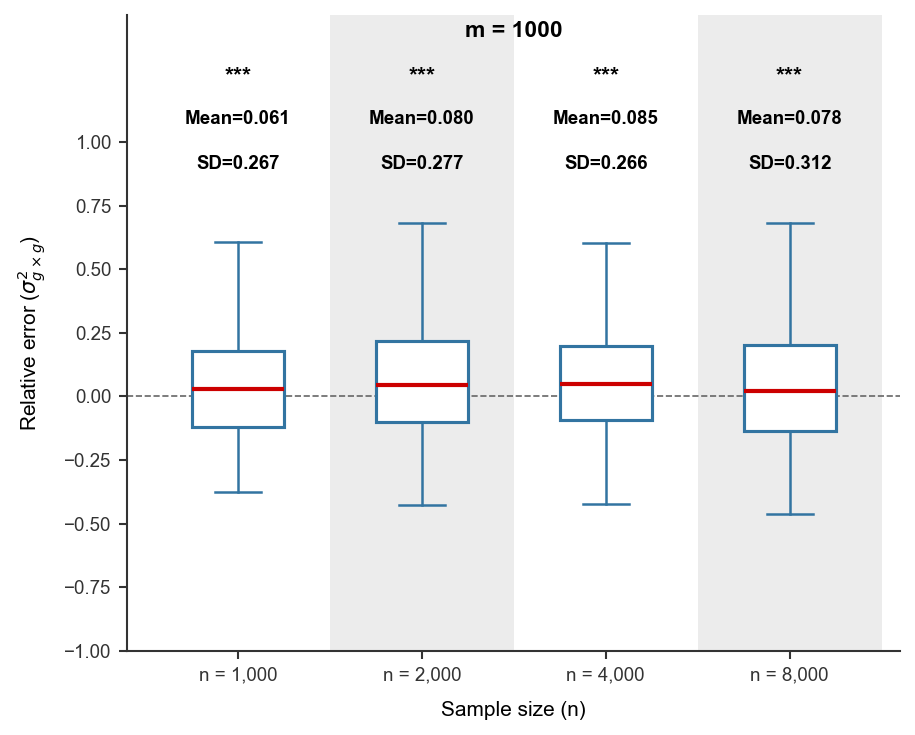

In [4]:
## example of boxplot
individual_sizes = [1000,2000,4000,8000]

plot_relative_error_across_groups_combined(
    exact_Contiguous_1k,
    x_labels=["m = 1000"],
    individual_sizes = [1000,2000,4000,8000],
    col_num=0,
    real_value=0.9,
    ymin=-1.0,
    ymax=1.0,
    save_name="relative_error_boxplot"  
)

PDF saved to: C:\Users\Ziyan Zhang\Desktop\Thesis\relative_error_boxplot.pdf


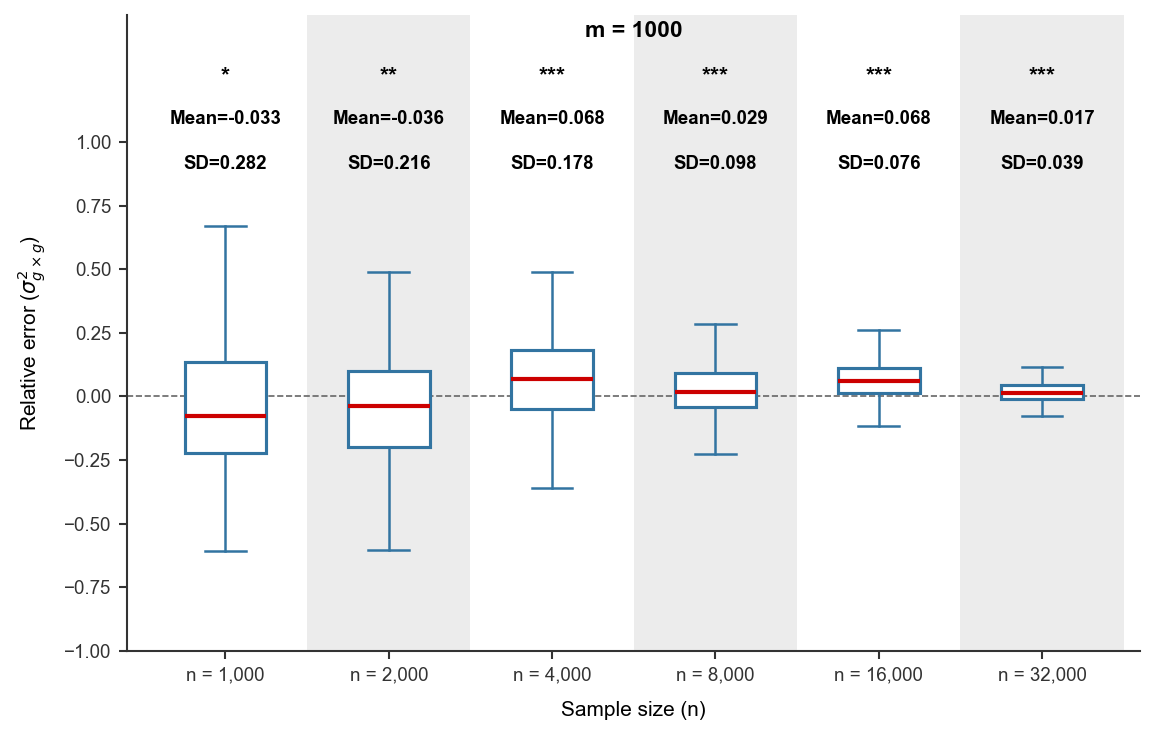

In [199]:
## example of boxplot
individual_sizes = [1000,2000,4000,8000,16000,32000]

plot_relative_error_across_groups_combined(
    Contiguous_raw_1k,
    x_labels=["m = 1000"],
    individual_sizes = [1000,2000,4000,8000,16000,32000],
    col_num=0,
    real_value=0.9,
    ymin=-1.0,
    ymax=1.0,
    save_name="relative_error_boxplot"  
)

PDF saved to: C:\Users\Ziyan Zhang\Desktop\Thesis\relative_error_combined_vertical.pdf


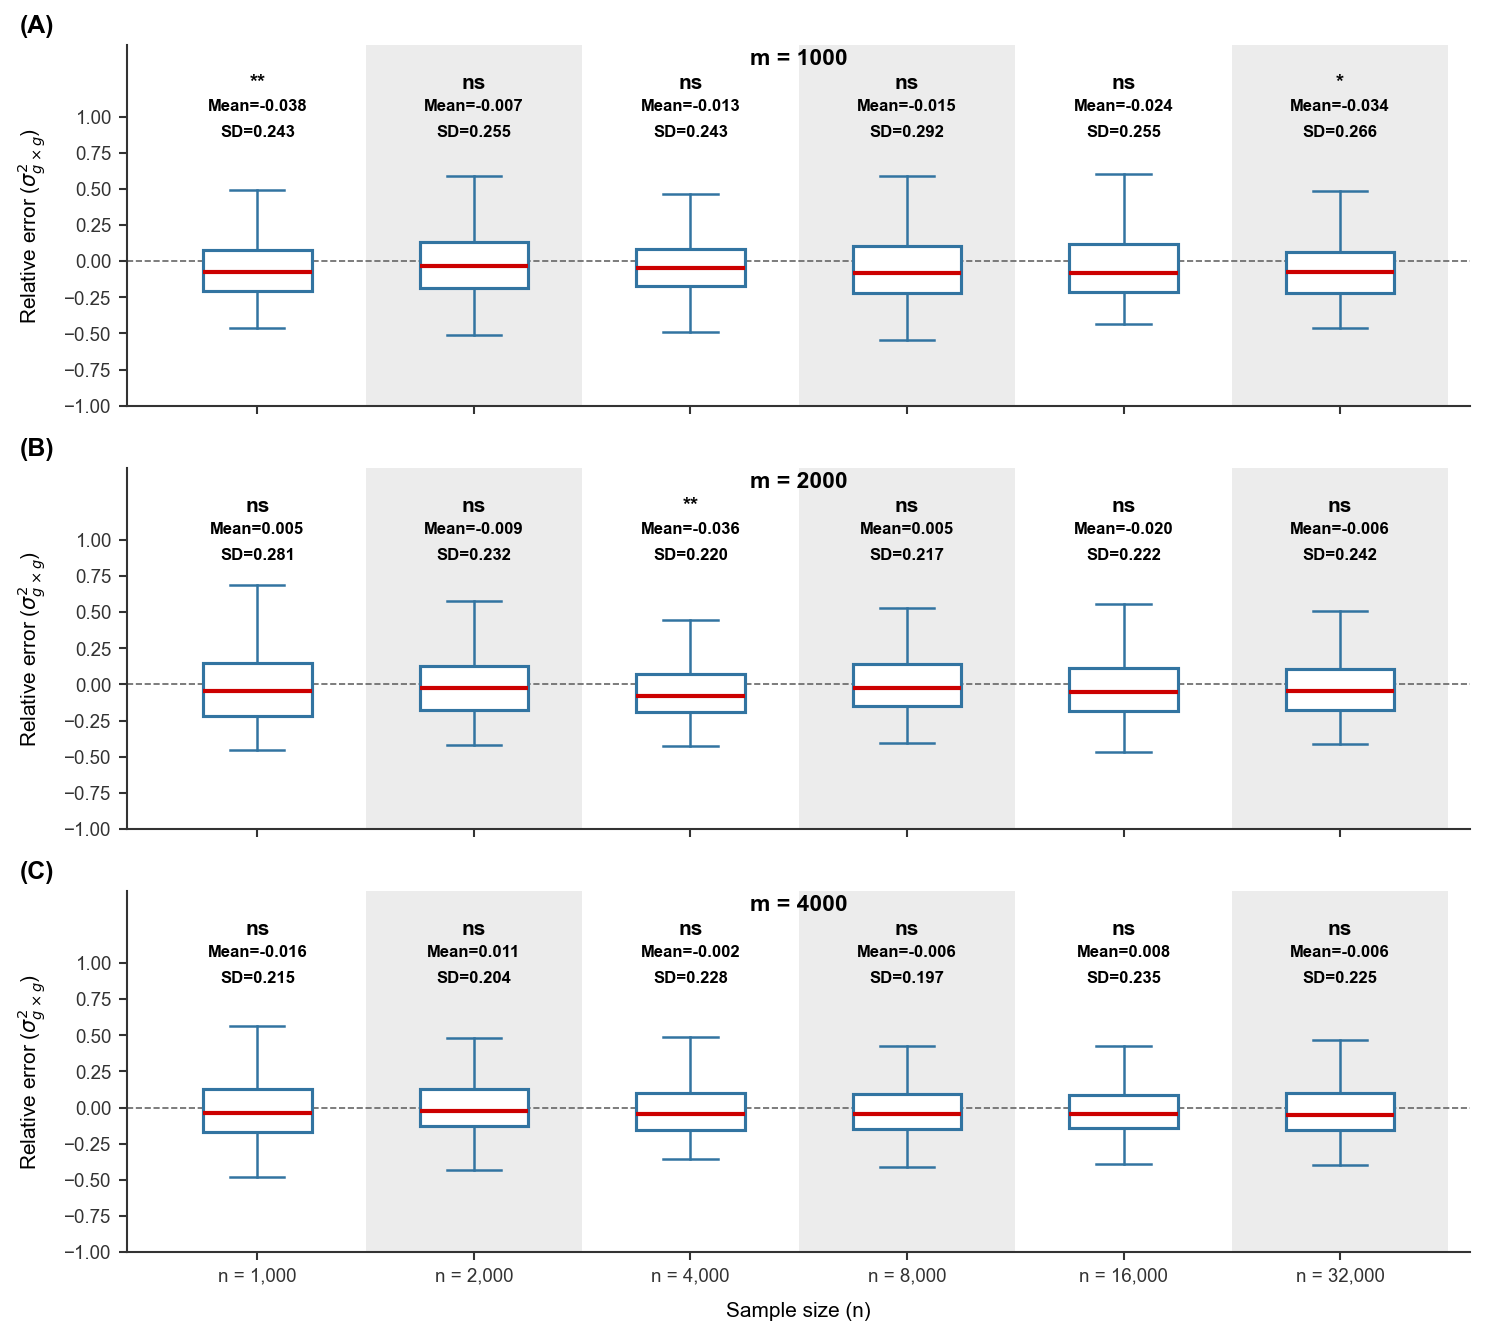

In [208]:
### read data
individual_sizes = [1000, 2000, 4000, 8000, 16000, 32000]
Contiguous_raw_1k = read_MoM_results(individual_sizes, "data/STD/", "infinitesimal_Contiguous_STD", 1000)
Contiguous_raw_2k = read_MoM_results(individual_sizes, "data/STD/", "infinitesimal_Contiguous_STD", 2000)
Contiguous_raw_4k = read_MoM_results(individual_sizes, "data/STD/", "infinitesimal_Contiguous_STD", 4000)

### Plot all three together (vertical, flattened)
plot_relative_error_combined_vertical(
    data_dicts_list=[Contiguous_raw_1k, Contiguous_raw_2k, Contiguous_raw_4k],
    x_labels_list=[["m = 1000"], ["m = 2000"], ["m = 4000"]],
    individual_sizes=[1000, 2000, 4000, 8000, 16000, 32000],
    col_num=0,
    real_value=0.9,
    ymin=-1.0,
    ymax=1.0,
    save_name="relative_error_combined_vertical"
)

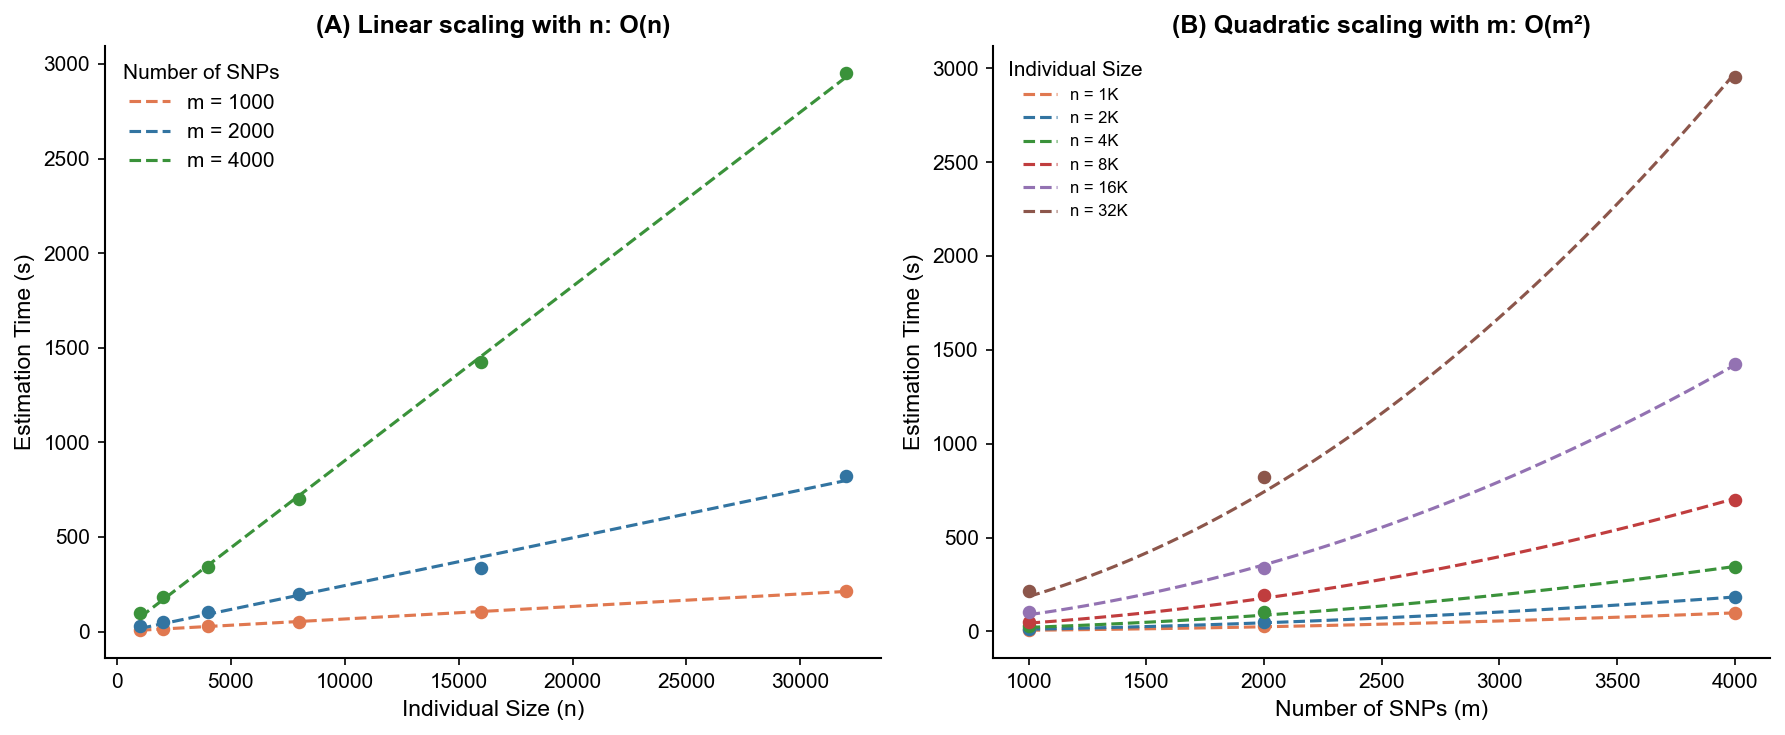

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define sample sizes and SNP counts
n_sizes = [1000, 2000, 4000, 8000, 16000, 32000]
m_sizes = [1000, 2000, 4000]

# Read all files and compute means
time_data = {}

for m in m_sizes:
    for n in n_sizes:
        df = pd.read_csv(f"data/time/n{n}m{m}time.txt", header=None)
        time_data[(n, m)] = df[0].mean()

# Set style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'axes.linewidth': 1,
    'figure.dpi': 150,
})

# Define fitting functions
def linear(x, a, b):
    return a * x + b

def quadratic_simple(x, a):
    return a * x**2

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# =============================================================================
# Left Plot: Time vs n (should be LINEAR)
# =============================================================================
colors_m = ['#E07850', '#3274A1', '#3A923A']

for i, m in enumerate(m_sizes):
    means = [time_data[(n, m)] for n in n_sizes]
    n_array = np.array(n_sizes)
    
    ax1.scatter(n_array, means, marker='o', s=30, color=colors_m[i], zorder=3)
    
    popt, _ = curve_fit(linear, n_array, means)
    n_fit = np.linspace(min(n_sizes), max(n_sizes), 100)
    ax1.plot(n_fit, linear(n_fit, *popt), '--', color=colors_m[i], linewidth=1.5,
             label=f'm = {m}')

ax1.set_xlabel('Individual Size (n)', fontsize=11)
ax1.set_ylabel('Estimation Time (s)', fontsize=11)
ax1.legend(title='Number of SNPs', frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('(A) Linear scaling with n: O(n)', fontsize=12, fontweight='bold', loc='center')

# =============================================================================
# Right Plot: Time vs m (should be QUADRATIC)
# =============================================================================
colors_n = ['#E07850', '#3274A1', '#3A923A', '#C03D3E', '#9372B2', '#8C564B']

for i, n in enumerate(n_sizes):
    means = [time_data[(n, m)] for m in m_sizes]
    m_array = np.array(m_sizes)
    
    ax2.scatter(m_array, means, marker='o', s=30, color=colors_n[i], zorder=3)
    
    popt, _ = curve_fit(quadratic_simple, m_array, means)
    m_fit = np.linspace(min(m_sizes), max(m_sizes), 100)
    ax2.plot(m_fit, quadratic_simple(m_fit, *popt), '--', color=colors_n[i], linewidth=1.5,
             label=f'n = {n//1000}K')

ax2.set_xlabel('Number of SNPs (m)', fontsize=11)
ax2.set_ylabel('Estimation Time (s)', fontsize=11)
ax2.legend(title='Individual Size', frameon=False, loc='upper left', fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('(B) Quadratic scaling with m: O(m²)', fontsize=12, fontweight='bold', loc='center')

plt.tight_layout()
plt.savefig('time_scaling.pdf', bbox_inches='tight', format='pdf')
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

In [207]:
import pandas as pd
import numpy as np
from scipy import stats

# Read the CSV
SE_Random_raw_n1000m1000 = pd.read_csv("data/SE/SE_Random_raw_n4000m1000.txt", header=None)

# Clean the first column - remove the opening parenthesis
SE_Random_raw_n1000m1000[0] = SE_Random_raw_n1000m1000[0].str.replace('(', '').astype(float)
ASE = np.sqrt(SE_Random_raw_n1000m1000[0])

# Calculate mean and SD
col1_mean = ASE.mean()
col1_sd = ASE.std()
n = len(ASE)

# Calculate 95% CI
se = col1_sd / np.sqrt(n)  # Standard error of the mean
ci_95 = 1.96 * se

# Or using t-distribution (more accurate for smaller samples)
ci_95_t = stats.t.ppf(0.975, df=n-1) * se

print(f"Mean: {col1_mean:.4f}")
print(f"SD: {col1_sd:.4f}")
print(f"n: {n}")
print(f"95% CI (z): {col1_mean:.4f} ± {ci_95:.4f}")
print(f"95% CI (t): {col1_mean:.4f} ± {ci_95_t:.4f}")
print(f"95% CI: [{col1_mean - ci_95:.4f}, {col1_mean + ci_95:.4f}]")

Mean: 0.1124
SD: 0.0045
n: 300
95% CI (z): 0.1124 ± 0.0005
95% CI (t): 0.1124 ± 0.0005
95% CI: [0.1119, 0.1129]


In [205]:
### read data
individual_sizes = [1000,2000,4000,8000,16000,32000]

Random_raw = read_MoM_results(individual_sizes,"data/raw_method/","Random_raw",1000)

In [206]:
# Get SD for first column of each n
for n in Random_raw.keys():
    df = Random_raw[n]
    col0_sd = df[0].std()
    print(f"n = {n}: SD = {col0_sd:.4f}")

n = 1000: SD = 0.2317
n = 2000: SD = 0.1636
n = 4000: SD = 0.1058
n = 8000: SD = 0.0720
n = 16000: SD = 0.0411
n = 32000: SD = 0.0230
